# ADHD EEG Preprocessing Notebook

This notebook provides a clean, step‑by‑step preprocessing pipeline for the EEG dataset in **adhdata.csv**.

We will:
- Load and validate the data
- Define EEG channel columns
- Apply a band‑pass filter (1–50 Hz)
- Segment the signal into fixed windows
- Extract basic statistical + band‑power features
- Save a clean feature table for ML models

## 1) Imports & Configuration
Adjust sampling rate and filter limits here.

In [1]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, welch

# ====== CONFIG ======
DATA_PATH = 'adhdata.csv'
SAMPLE_RATE = 128  # Hz
BANDPASS_LOW = 1.0
BANDPASS_HIGH = 50.0
FILTER_ORDER = 4
WINDOW_SEC = 2.0  # segment length
WINDOW_STEP_SEC = 1.0  # overlap step

# EEG channel columns in dataset (from CSV header)
EEG_CHANNELS = [
    'Fp1', 'Fp2', 'F3', 'F4',
    'C3', 'C4', 'P3', 'P4',
    'O1', 'O2', 'F7', 'F8',
    'T7', 'T8', 'P7', 'P8',
    'Fz', 'Cz', 'Pz'
]
# =====================

## 2) Load and Inspect Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,...,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,...,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


In [3]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Class distribution:')
print(df['Class'].value_counts())

Shape: (2166383, 21)
Columns: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Class', 'ID']
Class distribution:
Class
ADHD       1207069
Control     959314
Name: count, dtype: int64


## 3) Clean Columns and Labels
We keep only EEG channels + `ID` + `Class`.

In [4]:
needed_cols = ['ID', 'Class'] + EEG_CHANNELS
missing = [c for c in needed_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

df = df[needed_cols].copy()
df['Class'] = df['Class'].map({'ADHD': 1, 'Control': 0})
df.isna().sum().head()

ID       0
Class    0
Fp1      0
Fp2      0
F3       0
dtype: int64

## 4) Band‑Pass Filter
We apply a Butterworth band‑pass filter (1–50 Hz) using `filtfilt` for zero‑phase distortion.

In [5]:
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def filter_dataframe(df, channels, fs, lowcut, highcut, order=4):
    df_f = df.copy()
    for ch in channels:
        df_f[ch] = bandpass_filter(df_f[ch].values, fs, lowcut, highcut, order)
    return df_f

## 5) Segmentation
Segment each subject’s signal into overlapping windows (e.g., 2s windows with 1s step).

In [6]:
def segment_signal(data, window_size, step_size):
    segments = []
    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        segments.append(data[start:end])
    return np.stack(segments) if segments else np.empty((0, window_size, data.shape[1]))

## 12f) Deep Learning on Raw Windows (CNN1D + LSTM)
We build windowed EEG tensors (time × channels) and train CNN1D and LSTM models with subject‑level split.

In [7]:
# pyright: reportAttributeAccessIssue=false
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import json
import os
import random

# Deterministic settings (results vary by seed, but stable per seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

try:
    import tensorflow as tf
except ImportError as e:
    raise ImportError('TensorFlow is required for this cell. Please install tensorflow and re-run.') from e

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

def set_all_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def save_best_dl(model, metrics, model_path, meta_path):
    prev_best = None
    if os.path.exists(meta_path):
        with open(meta_path, 'r', encoding='utf-8') as f:
            prev_best = json.load(f).get('accuracy')
    if prev_best is None or metrics['accuracy'] > prev_best:
        model.save(model_path)
        with open(meta_path, 'w', encoding='utf-8') as f:
            json.dump(metrics, f, indent=2)
        print(f'Saved new best model to {model_path} (accuracy={metrics["accuracy"]:.4f})')
    else:
        print(f'Kept existing best model (accuracy={prev_best:.4f})')

def build_window_dataset(df, channels, fs, lowcut, highcut, order, window_sec, step_sec):
    window_size = int(window_sec * fs)
    step_size = int(step_sec * fs)
    Xw, yw, idw = [], [], []
    for pid, group in df.groupby('ID'):
        label = int(group['Class'].iloc[0])
        signals = group[channels].values
        # Filter per subject
        filtered = np.zeros_like(signals)
        for ch_idx in range(signals.shape[1]):
            filtered[:, ch_idx] = bandpass_filter(
                signals[:, ch_idx], fs, lowcut, highcut, order
            )
        # Segment
        segments = segment_signal(filtered, window_size, step_size)
        if segments.shape[0] == 0:
            continue
        Xw.append(segments)
        yw.append(np.full((segments.shape[0],), label))
        idw.append(np.full((segments.shape[0],), pid))
    Xw = np.vstack(Xw)
    yw = np.concatenate(yw)
    idw = np.concatenate(idw)
    return Xw, yw, idw

# Build raw window dataset
X_seq, y_seq, ids_seq = build_window_dataset(
    df, EEG_CHANNELS, SAMPLE_RATE, BANDPASS_LOW, BANDPASS_HIGH, FILTER_ORDER, WINDOW_SEC, WINDOW_STEP_SEC
)
print('Sequence data:', X_seq.shape, y_seq.shape)

# Subject-level split
gss_seq = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_seq, test_idx_seq = next(gss_seq.split(X_seq, y_seq, groups=ids_seq))
X_train_seq, X_test_seq = X_seq[train_idx_seq], X_seq[test_idx_seq]
y_train_seq, y_test_seq = y_seq[train_idx_seq], y_seq[test_idx_seq]
ids_train_seq, ids_test_seq = ids_seq[train_idx_seq], ids_seq[test_idx_seq]

# Z-score per channel using train stats
mean_ch = X_train_seq.mean(axis=(0,1), keepdims=True)
std_ch = X_train_seq.std(axis=(0,1), keepdims=True) + 1e-8
X_train_seq = (X_train_seq - mean_ch) / std_ch
X_test_seq = (X_test_seq - mean_ch) / std_ch

SEEDS = list(range(10))

for seed in SEEDS:
    print(f'\n=== Seed {seed} ===')
    set_all_seeds(seed)

    # CNN1D model
    cnn = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        tf.keras.layers.Conv1D(64, 5, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(128, 5, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    cnn.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
     )

    callbacks_cnn = [tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    cnn.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=30,
        batch_size=256,
        callbacks=callbacks_cnn,
        verbose=0
    )

    y_prob_cnn = cnn.predict(X_test_seq, verbose=0).ravel()
    y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
    acc_cnn = accuracy_score(y_test_seq, y_pred_cnn)
    f1_cnn = f1_score(y_test_seq, y_pred_cnn)
    print('CNN1D Test Accuracy:', acc_cnn)
    print('CNN1D Test F1:', f1_cnn)
    save_best_dl(cnn, {'accuracy': acc_cnn, 'f1': f1_cnn, 'seed': seed}, 'best_cnn.keras', 'best_cnn_meta.json')

    # # LSTM model
    # lstm = tf.keras.Sequential([
    #     tf.keras.layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    #     tf.keras.layers.LSTM(64, return_sequences=True),
    #     tf.keras.layers.Dropout(0.4),
    #     tf.keras.layers.LSTM(32),
    #     tf.keras.layers.Dropout(0.4),
    #     tf.keras.layers.Dense(1, activation='sigmoid')
    # ])
    # lstm.compile(
    #     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    #     loss='binary_crossentropy',
    #     metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    #  )

    # callbacks_lstm = [tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    # lstm.fit(
    #     X_train_seq, y_train_seq,
    #     validation_split=0.1,
    #     epochs=30,
    #     batch_size=256,
    #     callbacks=callbacks_lstm,
    #     verbose=0
    # )

    # y_prob_lstm = lstm.predict(X_test_seq, verbose=0).ravel()
    # y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)
    # acc_lstm = accuracy_score(y_test_seq, y_pred_lstm)
    # f1_lstm = f1_score(y_test_seq, y_pred_lstm)
    # print('LSTM Test Accuracy:', acc_lstm)
    # print('LSTM Test F1:', f1_lstm)
    # save_best_dl(lstm, {'accuracy': acc_lstm, 'f1': f1_lstm, 'seed': seed}, 'best_lstm.keras', 'best_lstm_meta.json')

# Print confusion matrix for the best saved CNN1D model
with open('best_cnn_meta.json', 'r', encoding='utf-8') as f:
    best_cnn_meta = json.load(f)

best_cnn_model = tf.keras.models.load_model('best_cnn.keras')
best_cnn_prob = best_cnn_model.predict(X_test_seq, verbose=0).ravel()
best_cnn_pred = (best_cnn_prob >= 0.5).astype(int)
best_cnn_cm = confusion_matrix(y_test_seq, best_cnn_pred)

print('\n=== Best Saved CNN1D Summary ===')
print('Best seed:', best_cnn_meta.get('seed'))
print('Best CNN1D Test Accuracy:', accuracy_score(y_test_seq, best_cnn_pred))
print('Best CNN1D Test F1:', f1_score(y_test_seq, best_cnn_pred))
print('Best CNN1D Confusion matrix:\n', best_cnn_cm)

Sequence data: (16749, 256, 19) (16749,)

=== Seed 0 ===
CNN1D Test Accuracy: 0.8879210220673636
CNN1D Test F1: 0.9007201646090535
Kept existing best model (accuracy=0.9271)

=== Seed 1 ===
CNN1D Test Accuracy: 0.8734030197444832
CNN1D Test F1: 0.898651789865179
Kept existing best model (accuracy=0.9271)

=== Seed 2 ===
CNN1D Test Accuracy: 0.8861788617886179
CNN1D Test F1: 0.9093851132686084
Kept existing best model (accuracy=0.9271)

=== Seed 3 ===
CNN1D Test Accuracy: 0.9073751451800233
CNN1D Test F1: 0.9272187999087383
Kept existing best model (accuracy=0.9271)

=== Seed 4 ===
CNN1D Test Accuracy: 0.9218931475029036
CNN1D Test F1: 0.9364216497281966
Kept existing best model (accuracy=0.9271)

=== Seed 5 ===
CNN1D Test Accuracy: 0.882404181184669
CNN1D Test F1: 0.9115527407730946
Kept existing best model (accuracy=0.9271)

=== Seed 6 ===
CNN1D Test Accuracy: 0.9001161440185831
CNN1D Test F1: 0.9156449239823443
Kept existing best model (accuracy=0.9271)

=== Seed 7 ===
CNN1D Test Acc

Saved confusion matrix image to: best_cnn_confusion_matrix_presentation.png


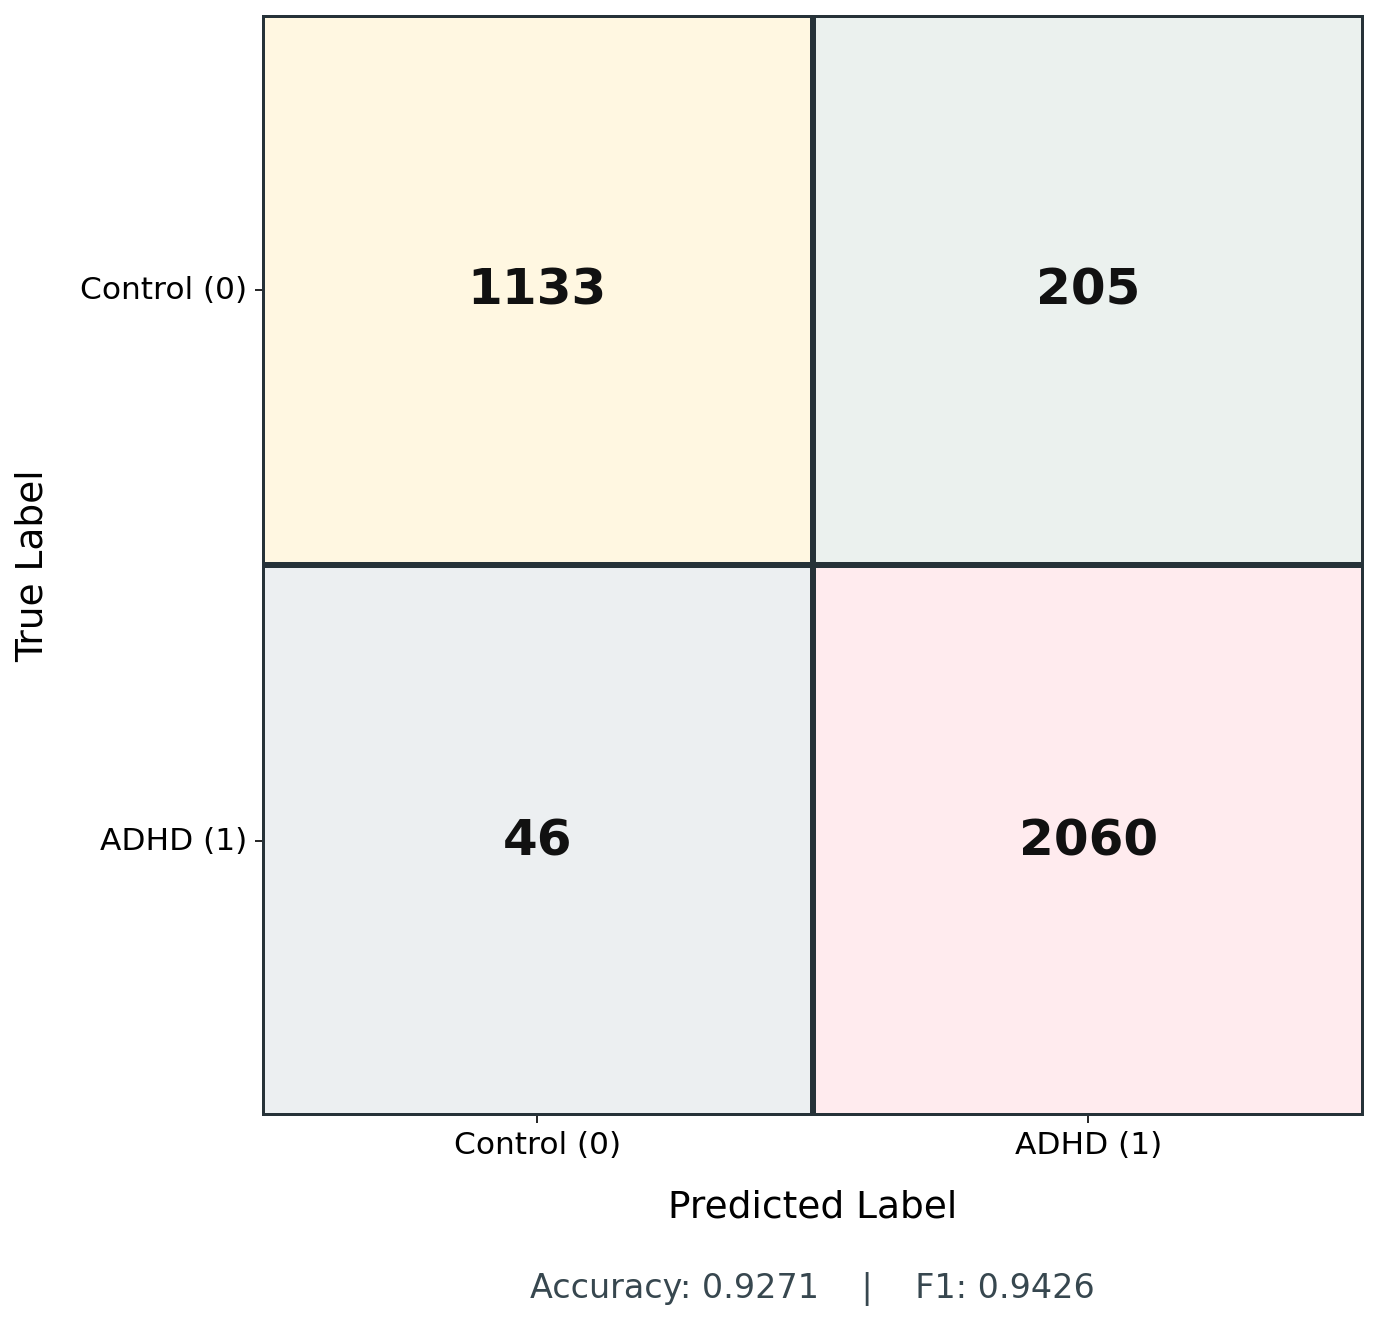

In [8]:
# 15) Presentation-ready confusion matrix image (Best CNN1D)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Image, display

# Values from the best saved CNN1D summary
best_seed = 8
best_acc = 0.9271196283391405
best_f1 = 0.9425760695493022
cm = np.array([[1133, 205],
               [46, 2060]])

out_cm_png = "best_cnn_confusion_matrix_presentation.png"

# Palette inspired by the architecture colors
cm_cmap = LinearSegmentedColormap.from_list(
    "cnn_arch_palette",
    ["#ECEFF1", "#E8F5E9", "#FFF8E1", "#FFF3E0", "#FFEBEE"]
)

# 16:9 canvas suitable for slides
fig = plt.figure(figsize=(16, 9), dpi=150)
ax = fig.add_subplot(111)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=cm_cmap,
    cbar=False,
    linewidths=2,
    linecolor="#263238",
    square=True,
    annot_kws={"fontsize": 24, "fontweight": "bold", "color": "#111111"},
    ax=ax
)

# ax.set_title("Best CNN1D Confusion Matrix", fontsize=30, fontweight="bold", pad=22)
ax.set_xlabel("Predicted Label", fontsize=18, labelpad=14)
ax.set_ylabel("True Label", fontsize=18, labelpad=14)
ax.set_xticklabels(["Control (0)", "ADHD (1)"], fontsize=15)
ax.set_yticklabels(["Control (0)", "ADHD (1)"], fontsize=15, rotation=0)

# Add model summary line in matching style
summary_line = f"Accuracy: {best_acc:.4f}    |    F1: {best_f1:.4f}"
fig.text(0.5, 0.04, summary_line, ha="center", va="center", fontsize=16, color="#37474F")

fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(out_cm_png, bbox_inches="tight")
plt.close(fig)

print(f"Saved confusion matrix image to: {out_cm_png}")
display(Image(filename=out_cm_png))

In [9]:
# 16) Best CNN subject-level evaluation
import json
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Load best CNN model and metadata
best_cnn_model = tf.keras.models.load_model('best_cnn.keras')
with open('best_cnn_meta.json', 'r', encoding='utf-8') as f:
    best_cnn_meta = json.load(f)

# Window-level probabilities on the existing test split
best_cnn_prob = best_cnn_model.predict(X_test_seq, verbose=0).ravel()

# Aggregate to subject-level via mean probability per subject
subj_true = []
subj_pred = []
for sid in np.unique(ids_test_seq):
    idx = ids_test_seq == sid
    true_label = int(np.round(np.mean(y_test_seq[idx])))
    mean_prob = float(np.mean(best_cnn_prob[idx]))
    pred_label = int(mean_prob >= 0.5)
    subj_true.append(true_label)
    subj_pred.append(pred_label)

subj_true = np.array(subj_true)
subj_pred = np.array(subj_pred)

subj_acc = accuracy_score(subj_true, subj_pred)
subj_f1 = f1_score(subj_true, subj_pred)
subj_cm = confusion_matrix(subj_true, subj_pred)

print('\n=== Best CNN1D Subject-Level Summary ===')
print('Best seed:', best_cnn_meta.get('seed'))
print('Number of test subjects:', len(subj_true))
print('Best CNN1D Subject-Level Accuracy:', subj_acc)
print('Best CNN1D Subject-Level F1:', subj_f1)
print('Best CNN1D Subject-Level Confusion matrix:\n', subj_cm)


=== Best CNN1D Subject-Level Summary ===
Best seed: 8
Number of test subjects: 25
Best CNN1D Subject-Level Accuracy: 0.92
Best CNN1D Subject-Level F1: 0.9333333333333333
Best CNN1D Subject-Level Confusion matrix:
 [[ 9  2]
 [ 0 14]]
